In [1]:
import torch
import torch.nn as nn
from torch import optim
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay, classification_report

In [2]:
class FFNN(nn.Module):
    """
    Defines a feedforward neural network for binary classification over a single datapoint at a time.
    This consists of matrix multiplications with ReLU nonlinearities and a log softmax output layer.
    """
    def __init__(self, inp, hid, out):
        """
        Constructs the computation graph by instantiating the various layers and initializing weights.

        :param inp: size of input (integer)
        :param hid: size of hidden layer (integer)
        :param out: size of output (integer), which should be the number of classes
        """
        super(FFNN, self).__init__()
        self.V = nn.Linear(inp, hid)
        self.g = nn.ReLU()
        self.W = nn.Linear(hid, out)
        self.log_softmax = nn.LogSoftmax(dim=0)

    def forward(self, x):
        """
        Runs the neural network on the given data and returns log probabilities of the various classes.

        :param x: a [inp]-sized tensor of input data
        :return: an [out]-sized tensor of log probabilities
        """
        return self.log_softmax(self.W(self.g(self.V(x))))


def form_input(x) -> torch.Tensor:
    """
    Form the input to the neural network.

    :param x: a numpy array containing input data
    :return: a Tensor
    """
    return torch.from_numpy(x).float()

In [3]:
RANDOM_STATE = 0
PATH = "dataset.csv"
POPULAR_THRESHOLD = 70

feat_cols = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms", "key", "mode", "time_signature", "explicit"]

In [4]:
df = pd.read_csv(PATH)

popularity_scores = df["popularity"]
is_popular = popularity_scores >= POPULAR_THRESHOLD
df["label_popular"] = is_popular

feat_table = df[feat_cols]

feat_medians = feat_table.median()
new_feat = feat_table.fillna(feat_medians)

X = new_feat.to_numpy()
y = df["label_popular"].to_numpy().astype(np.float32)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

In [6]:
train_size = X_train_scaled.shape[0]
test_size = X_test_scaled.shape[0]
print("Train size: " + str(train_size))
print("Test size: " + str(test_size))

Train size: 91200
Test size: 22800


In [7]:

feat_size = X_train_scaled.shape[1]
embed_size = 64
n_classes = 2

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


pos_count = np.sum(y_train == 1)
neg_count = np.sum(y_train == 0)
pos_weight = neg_count / pos_count

epochs = 50
ffnn = FFNN(feat_size, embed_size, n_classes)
lRate = 0.01
optimizer = optim.SGD(ffnn.parameters(), lr=lRate)

train_loss_history = []
for epoch in range(1, epochs+1):
    ex_indices = [i for i in range(0, len(X_train_scaled))]
    random.shuffle(ex_indices)
    total_loss = 0.0
    for idx in ex_indices:
        x = form_input(X_train_scaled[idx])
        y_val = y_train[idx]

        y_onehot = torch.zeros(n_classes)
        y_onehot.scatter_(0, torch.from_numpy(np.asarray(y_val, dtype=np.int64)), 1)

        ffnn.zero_grad()
        log_probs = ffnn.forward(x)

        loss = torch.neg(log_probs).dot(y_onehot)
        if y_val == 1:
            loss = loss * pos_weight
        total_loss += loss

        loss.backward()
        optimizer.step()
    train_loss_history.append(total_loss.item())
    if epoch % 5 == 0:
        print("Total loss on epoch %i: %f" % (epoch, total_loss))

Total loss on epoch 5: 115143.078125
Total loss on epoch 10: 115692.734375
Total loss on epoch 15: 116584.054688
Total loss on epoch 20: 115112.765625
Total loss on epoch 25: 115451.171875
Total loss on epoch 30: 114644.671875
Total loss on epoch 35: 114406.789062
Total loss on epoch 40: 114446.328125
Total loss on epoch 45: 115329.617188
Total loss on epoch 50: 114611.500000


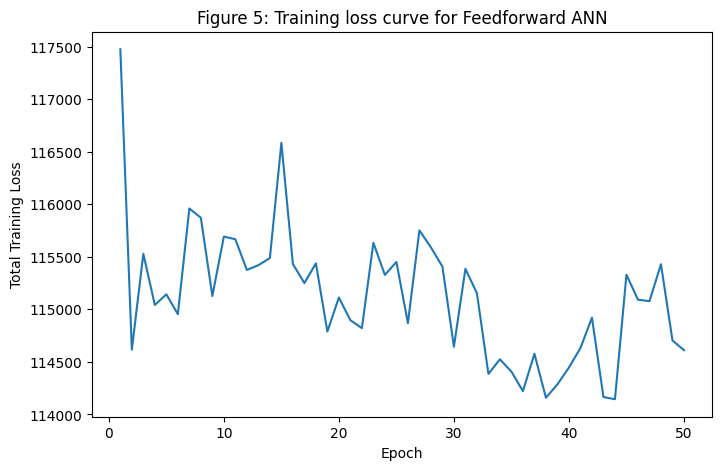

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_loss_history, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Total Training Loss")
plt.title("Figure 5: Training loss curve for Feedforward ANN")
plt.show()

In [9]:
threshold = 0.5
test_popular_proba = []

for idx in range(0, len(X_test_scaled)):
    x = form_input(X_test_scaled[idx])
    log_probs = ffnn.forward(x)

    probs = torch.exp(log_probs)
    popular_prob = probs[1].item()
    test_popular_proba.append(popular_prob)

test_popular_proba = np.array(test_popular_proba)
y_test_pred = test_popular_proba >= threshold

In [10]:
accuracy = accuracy_score(y_test, y_test_pred)
error = 1.0 - accuracy
precision = precision_score(y_test, y_test_pred, pos_label=True)
recall = recall_score(y_test, y_test_pred, pos_label=True)
f1_metric = f1_score(y_test, y_test_pred, pos_label=True)
roc_auc = roc_auc_score(y_test, test_popular_proba)
confusion = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:")
print(confusion)
print("")
print("Threshold: " + str(threshold))
print("Accuracy: " + str(accuracy))
print("Error: " + str(error))
print("Precision: " + str(precision))
print("Recall: " + str(recall))
print("F1 score: " + str(f1_metric))
print("ROC-AUC: " + str(roc_auc))

print("")
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=["not_popular", "popular"]))

roc_false_positive_rate, roc_true_positive_rate, roc_threshold_values = roc_curve(
    y_test, test_popular_proba
)

Confusion matrix:
[[18305  3401]
 [  671   423]]

Threshold: 0.5
Accuracy: 0.8214035087719298
Error: 0.1785964912280702
Precision: 0.11061715481171548
Recall: 0.386654478976234
F1 score: 0.17202114680764538
ROC-AUC: 0.6760530580597519

Classification report:
              precision    recall  f1-score   support

 not_popular       0.96      0.84      0.90     21706
     popular       0.11      0.39      0.17      1094

    accuracy                           0.82     22800
   macro avg       0.54      0.61      0.54     22800
weighted avg       0.92      0.82      0.86     22800



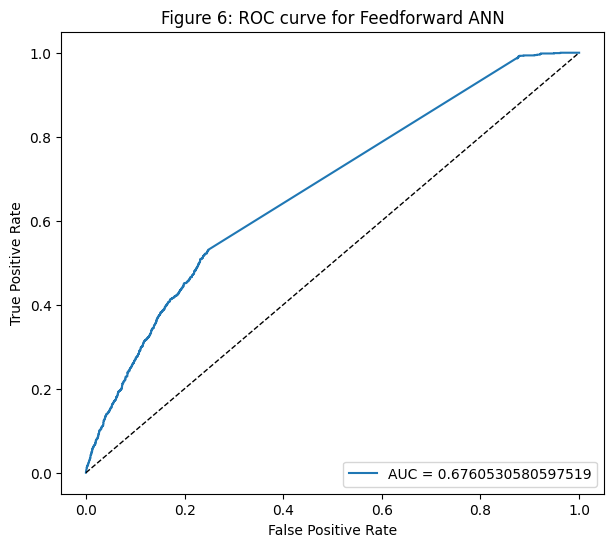

In [11]:
plt.figure(figsize=(7, 6))
auc_label = "AUC = " + str(roc_auc)
plt.plot(roc_false_positive_rate, roc_true_positive_rate, label=auc_label)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 6: ROC curve for Feedforward ANN")
plt.legend(loc="lower right")
plt.show()

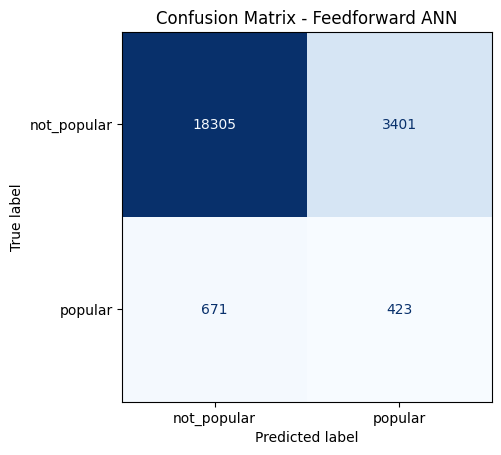

In [12]:
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["not_popular", "popular"],
)
confusion_matrix_display.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Feedforward ANN")
plt.show()